In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import awkward as ak
import pickle
import energyflow as ef
import fastjet as fj
import utils
import visualize as vis

In [3]:
import sys
sys.path.append("../utils")
import data_utils as du  # noqa: E402
import jet_clusterer

In [4]:
# Get TTree and pass 190 flags
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_5Jul2025_MGPy8FxFxPlusNonStrong_syst_Test_withdd.root"
)
t = f["OmniTree"]
pass190 = ak.to_numpy(t["truth_pass190"].array())

f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
)
t_pd = f_pd["OmniTree"]
pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5.root"
)
t_hv = f_hv["OmniTree"]
pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())

f_data = uproot.open(
    "/pscratch/sd/k/kgreif/data/ZjetOmnifold_Nov11_data_WithTracks_slim_Systematics_shuffled.root"
)
t_data = f_data["OmniTree"]
pass190_data = np.ones(t_data.num_entries)

In [5]:
# For the sherpa prediction, need to use multiple files since they are difficult to hadd
sherpa_files = [f"/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/sherpa/ZjetOmnifold_30Jul2025_Sherpa2211Truth_{syst}.root" for syst in ["mc16a_BFilter", "mc16d_BFilter", "mc16e_BFilter", "mc16a_CFilterBVeto", "mc16d_CFilterBVeto", "mc16e_CFilterBVeto", "mc16a_CVetoBVeto", "mc16d_CVetoBVeto", "mc16e_CVetoBVeto"]]
sherpa_files.append(
    "/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/sherpa/ZjetOmnifold_19Jun2025_NonStrong_posWrew_systJetIndex_Test.root"
)
sherpa_trees = [uproot.open(file)["OmniTree"] for file in sherpa_files]
sherpa_pass190 = [ak.to_numpy(tree["truth_pass190"].array()) for tree in sherpa_trees]

In [6]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 750.0
ptmax = 100000
etamax = 1.2

In [ ]:
# Calculate EMDs for truth MC
utils.calculate_emds_from_file(
    t,
    pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    save_path="./emd_storage/truth_mc_750plus.npz",
)

In [ ]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    t_pd,
    pass190_pd,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_pd_750plus.npz",
)

In [ ]:
# Calculate EMDs for HV MC
utils.calculate_emds_from_file(
    t_hv,
    pass190_hv,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_hv_750plus.npz",
)

In [ ]:
# Calculate EMDs for data
utils.calculate_emds_from_file(
    t_data,
    pass190_data,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=False,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/reco_data_750plus.npz",
)

In [ ]:
# Calculate EMDs for Sherpa
utils.calculate_emds_from_file(
    sherpa_trees,
    sherpa_pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_sherpa_750plus.npz",
)

In [ ]:
# Load the weights from Omnifold and ROOT files
of_pseudodata = np.load("../weight_storage/zjets-v4/pd-weights.npz")

In [ ]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
nominal_emds = "./emd_storage/truth_mc_750plus.npz"
truthpd_emds = "./emd_storage/truth_pd_750plus.npz"
hv_emds = "./emd_storage/truth_hv_750plus.npz"
data_emds = "./emd_storage/reco_data_750plus.npz"

nominal_root_weights = ak.to_numpy(t["weight_mc"].array())
hv_root_weights = ak.to_numpy(t_hv["weight_mc"].array())
nominal_weights = {
    "prior": nominal_root_weights[pass190 == 1],
    "nominal": np.array(of_pseudodata["nominal-central"] * nominal_root_weights)[pass190 == 1],
    **{f"nn-init-{i}": np.array(of_pseudodata[f"nominal-{i}"] * nominal_root_weights)[pass190 == 1] for i in range(10)},
    "track-eff": np.array(of_pseudodata["track-eff-central"] * nominal_root_weights)[pass190 == 1],
    "jet-track-eff": np.array(of_pseudodata["jet-track-eff-central"] * nominal_root_weights)[pass190 == 1],
    "track-fake": np.array(of_pseudodata["track-fake-central"] * nominal_root_weights)[pass190 == 1],
    "track-scale": np.array(of_pseudodata["track-scale-central"] * nominal_root_weights)[pass190 == 1],
    "muon-id": np.array(of_pseudodata["muon-id-central"] * nominal_root_weights)[pass190 == 1],
    "muon-ms": np.array(of_pseudodata["muon-ms-central"] * nominal_root_weights)[pass190 == 1],
    "muon-resbias": np.array(of_pseudodata["muon-resbias-central"] * nominal_root_weights)[pass190 == 1],
    "muon-scale": np.array(of_pseudodata["muon-scale-central"] * nominal_root_weights)[pass190 == 1],
    "dd": np.array(of_pseudodata["dd-central"] * nominal_root_weights)[pass190 == 1],
    "dd-target": ak.to_numpy(t["target_dd"].array())[pass190 == 1],
}
truthpd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[pass190_pd == 1],
}
hv_weights = {
    "hv": np.array(of_pseudodata["hv-central"] * hv_root_weights)[pass190_hv == 1],
}
data_weights = {
    "data-stat": np.ones(t_data.num_entries),
}


In [ ]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(150), 100)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins, n_jobs=-1
)
truthpd_hists = utils.calculate_correlation_dimension_from_file(
    truthpd_emds, truthpd_weights, bins
)
hv_hists = utils.calculate_correlation_dimension_from_file(
    hv_emds, hv_weights, bins
)
data_hists = utils.calculate_correlation_dimension_from_file(
    data_emds, data_weights, bins
)

all_hists = {
    **nominal_hists,
    **truthpd_hists,
    **hv_hists,
    **data_hists,
}

In [ ]:
# Pickle the histograms
with open("./hist_storage/pd_hists_750plus.pkl", "wb") as f:
    pickle.dump(all_hists, f)


In [26]:
# Load the histograms
with open("./hist_storage/pd_hists_750plus_coarse.pkl", "rb") as f:
    all_hists = pickle.load(f)

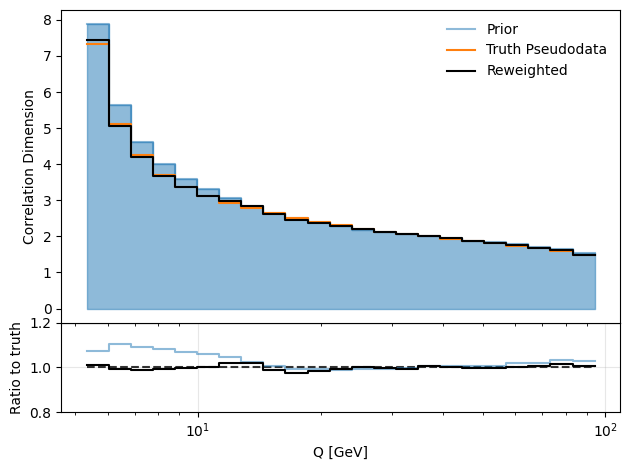

In [27]:
# Plot comparison to truth pseudodata in fine bins (no uncertainties)
comp = vis.compare_to_target(
    all_hists,
    log_xscale=True,
    linear_yscale=True,
    ylabel="Correlation Dimension",
    xlabel="Q [GeV]",
)

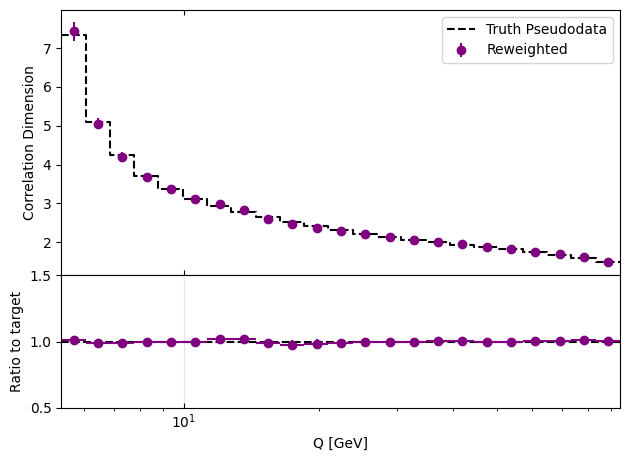

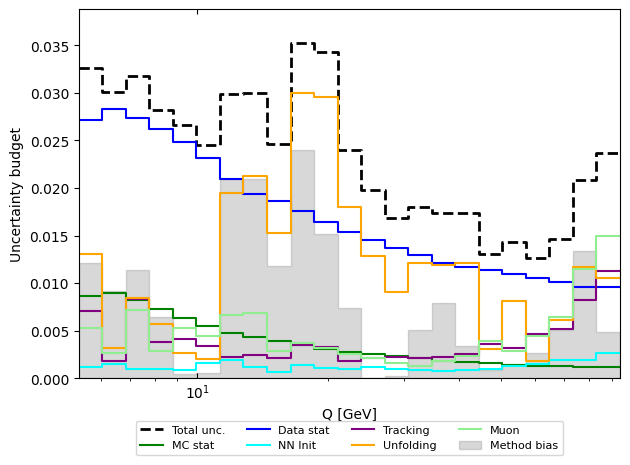

In [28]:
# Plot pseudo-measurement and uncertainty budget
xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    figsize=(6.4, 4.8),
    color="purple",
    linear_yscale=True,
)
xsec.show()
budget.show()

In [7]:
# Load the weights for the data measurement
of_data = np.load("../weight_storage/zjets-v4/data-weights.npz")

In [16]:
# Create dictionary describing all of the histograms needed for the data measurement
nominal_emds = "./emd_storage/truth_mc_750plus.npz"
hv_emds = "./emd_storage/truth_hv_750plus.npz"
data_emds = "./emd_storage/reco_data_750plus.npz"
sherpa_emds = "./emd_storage/truth_sherpa_750plus.npz"

nominal_root_weights = ak.to_numpy(t["weight_mc"].array())
hv_root_weights = ak.to_numpy(t_hv["weight_mc"].array())
nominal_weights = {
    "madgraph": nominal_root_weights[pass190 == 1],
    "nominal": np.array(of_data["nominal-central"] * nominal_root_weights)[pass190 == 1],
    **{
        f"nn-init-{i}": np.array(of_data[f"nominal-{i}"] * nominal_root_weights)[
            pass190 == 1
        ]
        for i in range(10)
    },
    "track-eff": np.array(of_data["track-eff-central"] * nominal_root_weights)[pass190 == 1],
    "jet-track-eff": np.array(of_data["jet-track-eff-central"] * nominal_root_weights)[
        pass190 == 1
    ],
    "track-fake": np.array(of_data["track-fake-central"] * nominal_root_weights)[
        pass190 == 1
    ],
    "track-scale": np.array(of_data["track-scale-central"] * nominal_root_weights)[
        pass190 == 1
    ],
    "muon-id": np.array(of_data["muon-id-central"] * nominal_root_weights)[pass190 == 1],
    "muon-ms": np.array(of_data["muon-ms-central"] * nominal_root_weights)[pass190 == 1],
    "muon-resbias": np.array(of_data["muon-resbias-central"] * nominal_root_weights)[
        pass190 == 1
    ],
    "muon-scale": np.array(of_data["muon-scale-central"] * nominal_root_weights)[
        pass190 == 1
    ],
    "dd": np.array(of_data["dd-central"] * nominal_root_weights)[pass190 == 1],
    "dd-target": ak.to_numpy(t["target_dd"].array())[pass190 == 1],
}
hv_weights = {
    "hv": np.array(of_data["hv-central"] * hv_root_weights)[pass190_hv == 1],
}
data_weights = {
    "data-stat": np.ones(t_data.num_entries),
}
sherpa_weights = []
for i, tree in enumerate(sherpa_trees):
    sherpa_weights.append(ak.to_numpy(tree["weight_mc"].array())[sherpa_pass190[i] == 1])
sherpa_weights = {"sherpa": np.concatenate(sherpa_weights)}

In [29]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(100), 25)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins, n_jobs=-1
)
hv_hists = utils.calculate_correlation_dimension_from_file(hv_emds, hv_weights, bins)
data_hists = utils.calculate_correlation_dimension_from_file(
    data_emds, data_weights, bins
)
sherpa_hists = utils.calculate_correlation_dimension_from_file(
    sherpa_emds, sherpa_weights, bins
)

all_hists = {
    **nominal_hists,
    **hv_hists,
    **data_hists,
    **sherpa_hists,
}

Loading EMDs from ./emd_storage/truth_mc_750plus.npz...
Loaded EMDs with shape (38604, 38604)
Loaded event indices with shape (38604,)
Processing 22 weight sets with 22 parallel workers...
Calculating correlation dimension for 'madgraph'...
Calculating correlation dimension for 'nominal'...
Calculating correlation dimension for 'nn-init-0'...
Calculating correlation dimension for 'nn-init-1'...
Calculating correlation dimension for 'nn-init-2'...
Calculating correlation dimension for 'nn-init-3'...
Calculating correlation dimension for 'nn-init-4'...
Calculating correlation dimension for 'nn-init-5'...
Calculating correlation dimension for 'nn-init-6'...
Calculating correlation dimension for 'nn-init-7'...
Calculating correlation dimension for 'nn-init-8'...
Calculating correlation dimension for 'nn-init-9'...
Calculating correlation dimension for 'track-eff'...
Calculating correlation dimension for 'jet-track-eff'...
Calculating correlation dimension for 'track-fake'...
Calculating co

In [30]:
# Pickle the histograms
with open("./hist_storage/data_hists_750plus_coarse.pkl", "wb") as f:
    pickle.dump(all_hists, f)

In [31]:
# Load the histograms
with open("./hist_storage/data_hists_750plus_coarse.pkl", "rb") as f:
    all_hists = pickle.load(f)

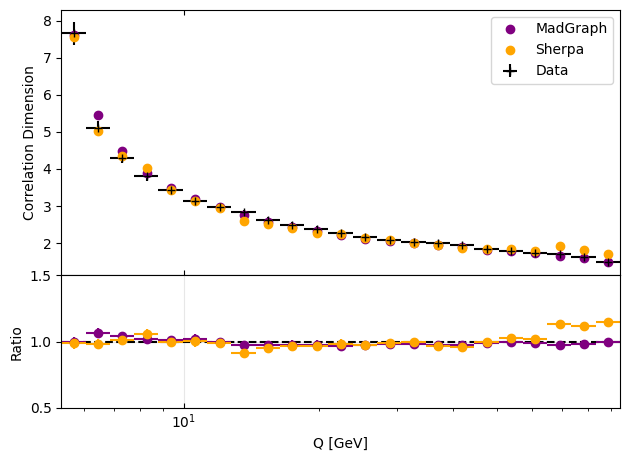

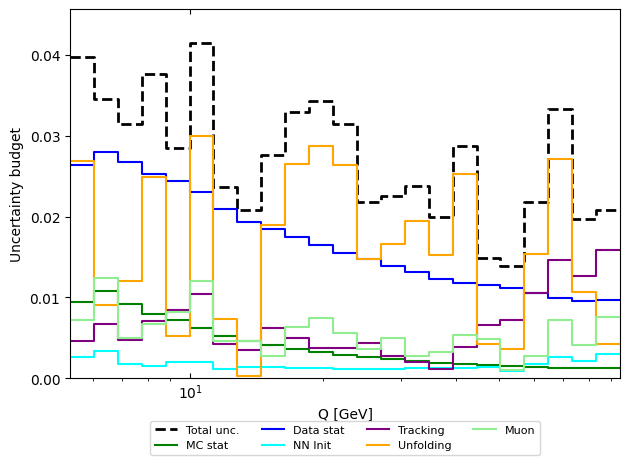

In [32]:
# Plot data measurement and uncertainty budget
xsec, budget = vis.plot_measurement_with_uncertainties(
    all_hists,
    measured_label="Data",
    target_key="madgraph",
    target_label="MadGraph",
    target2_key="sherpa",
    target2_label="Sherpa",
    data_measurement_mode=True,
    color="black",
    linear_yscale=True,
)
xsec.show()
budget.show()